# 3. 승인매출정보 (승인/매출 정보) EDA

카테고리 3 = **얼마나 쓰나 (소비 행동)**. 406개 컬럼으로 8개 테이블 중 가장 넓다.
라벨 `Segment`는 이 테이블에 없으므로 **회원정보(카테고리 1)에서 조인**한다.

**사전 발견 (01 회원정보 EDA)**: Segment는 이용/가치 등급(A상위~E하위)의 **순서형**에 가깝고, 소비 피처가 지배적일 것으로 예상됨. → 이 카테고리가 핵심.

**컬럼 구조**: `이용금액 / 이용건수 / 이용개월수`(95/76/46) × 상품유형(신용·신판·일시불·할부·유이자·무이자·CA·체크·카드론·온라인·오프라인·페이…) × 기간(`B0M`당월 / `R3M` / `R6M` / `R12M`). 즉 **소비의 규모·빈도·최근성·구성**을 다각도로 기록.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 200); pd.set_option('display.width', 220)

import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH = '201812'
SEG_ORDER = ['A','B','C','D','E']
SEG_COLORS = {'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812 승인매출) + 라벨 조인 (회원정보)

In [2]:
f3 = glob.glob(os.path.join(ROOT,'train','3.*',f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f3)

f1 = glob.glob(os.path.join(ROOT,'train','1.*',f'{MONTH}_*.parquet'))[0]
lbl = pd.read_parquet(f1, columns=['ID','Segment'])

df = df.merge(lbl, on='ID', how='left')
assert df['Segment'].notna().all(), '라벨 조인 실패(정합성 이슈)'  # 사전검증상 100% 매칭
print('shape:', df.shape, '| 라벨 결측:', int(df['Segment'].isna().sum()))
df[['ID','Segment']].head(3)

shape: (400000, 407) | 라벨 결측: 0


,ID,Segment
0,TRAIN_000000,D
1,TRAIN_000001,E
2,TRAIN_000002,C


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

In [3]:
meta = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'missing_%': (df.isna().mean()*100).round(2),
    'nunique': df.nunique(dropna=True),
})
print('dtype 분포:'); print(meta['dtype'].value_counts().to_string())
print('\n결측 있는 컬럼 (missing%>0):')
print(meta[meta['missing_%']>0].sort_values('missing_%', ascending=False)[['dtype','missing_%','nunique']].to_string())

dtype 분포:
dtype
int64      385
str         19
float64      3

결측 있는 컬럼 (missing%>0):
                  dtype  missing_%  nunique
_3순위여유업종            str      99.74        5
_2순위여유업종            str      98.46        7
_3순위납부업종            str      96.38        4
_1순위여유업종            str      89.61        7
_3순위교통업종            str      86.29        5
_2순위납부업종            str      85.39        5
최종카드론_대출일자      float64      82.85     1666
최종카드론_신청경로코드        str      81.55        5
최종카드론_금융상환방식코드  float64      81.54        3
_2순위교통업종            str      70.18        6
_3순위쇼핑업종            str      55.42        8
_1순위납부업종            str      52.05        5
_1순위교통업종            str      49.63        5
_2순위쇼핑업종            str      48.30        8
_3순위업종              str      47.84       10
_1순위쇼핑업종            str      40.06        8
_2순위업종              str      39.69       10
_1순위업종              str      23.83       10


### 2-1. 버릴 후보 — 상수 컬럼 & 고결측 컬럼

In [4]:
const_cols = meta.index[meta['nunique'] <= 1].tolist()
high_missing = meta.index[meta['missing_%'] >= 40].tolist()
print(f'상수 컬럼 {len(const_cols)}개 (분산 0 → 제거):')
print(const_cols)
print(f'\n고결측(>=40%) {len(high_missing)}개 — 대부분 2·3순위 업종(=해당 소비 없음). 결측=미소비 신호:')
print(high_missing)

상수 컬럼 43개 (분산 0 → 제거):
['기준년월', '이용건수_부분무이자_B0M', '이용금액_부분무이자_B0M', '이용건수_부분무이자_R6M', '이용금액_부분무이자_R6M', '이용건수_부분무이자_R3M', '이용금액_부분무이자_R3M', '이용개월수_부분무이자_R3M', '여유_여행이용금액', '납부_렌탈료이용금액', '납부_유선방송이용금액', '납부_건강연금이용금액', '할부건수_무이자_14M_R12M', '할부건수_부분_3M_R12M', '할부건수_부분_6M_R12M', '할부건수_부분_14M_R12M', '할부금액_부분_3M_R12M', '할부금액_부분_6M_R12M', 'RP건수_유선방송_B0M', 'RP건수_건강_B0M', 'RP후경과월_유선방송', 'RP후경과월_건강', '증감_RP건수_유선방송_전월', '증감_RP건수_건강_전월', '이용개월수_당사페이_R6M', '이용개월수_당사기타_R6M', '이용금액_당사페이_R6M', '이용금액_당사기타_R6M', '이용건수_당사페이_R6M', '이용건수_당사기타_R6M', '이용금액_당사페이_R3M', '이용금액_당사기타_R3M', '이용건수_당사페이_R3M', '이용건수_당사기타_R3M', '이용금액_당사페이_B0M', '이용금액_당사기타_B0M', '이용건수_당사페이_B0M', '이용건수_당사기타_B0M', '신청건수_ATM_CL_B0', '승인거절건수_입력오류_B0M', '승인거절건수_기타_B0M', '승인거절건수_입력오류_R3M', '승인거절건수_기타_R3M']

고결측(>=40%) 16개 — 대부분 2·3순위 업종(=해당 소비 없음). 결측=미소비 신호:
['_3순위업종', '_1순위쇼핑업종', '_2순위쇼핑업종', '_3순위쇼핑업종', '_1순위교통업종', '_2순위교통업종', '_3순위교통업종', '_1순위여유업종', '_2순위여유업종', '_3순위여유업종', '_1순위납부업종', '_2순위납부업종', '_3순위납부업종', '최종카드론_금융상환방식코드', '최종카드론_신청경로코드'

## 3. 세그먼트별 소비 규모 (핵심 지표)

순서형 가설(A>...>E)이 소비 지표에서 실제로 성립하는지, 당월(B0M)·최근3/6/12개월 이용금액으로 확인.

In [5]:
spend_cols = [c for c in df.columns if c.startswith('이용금액_신용_') or c.startswith('이용금액_신판_')]
# 대표 지표: 이용금액 신용 (일시불+할부+CA+카드론) 각 기간
rep = [c for c in ['이용금액_신용_B0M','이용금액_신용_R3M','이용금액_신용_R6M','이용금액_신용_R12M',
                    '이용건수_신용_B0M','이용건수_신용_R3M','이용개월수_신용_R6M','이용개월수_신용_R12M'] if c in df.columns]
g = df.groupby('Segment')[rep].median().reindex(SEG_ORDER)
print('세그먼트별 중앙값 (대표 소비지표):')
print(g.T.to_string())

세그먼트별 중앙값 (대표 소비지표):
Segment            A      B      C     D     E
이용건수_신용_B0M     62.0   57.5   35.0  24.0   3.0
이용건수_신용_R3M    184.0  181.0  107.0  73.0   9.0
이용개월수_신용_R6M     6.0    6.0    6.0   6.0   6.0
이용개월수_신용_R12M   12.0   12.0   12.0  12.0  10.0


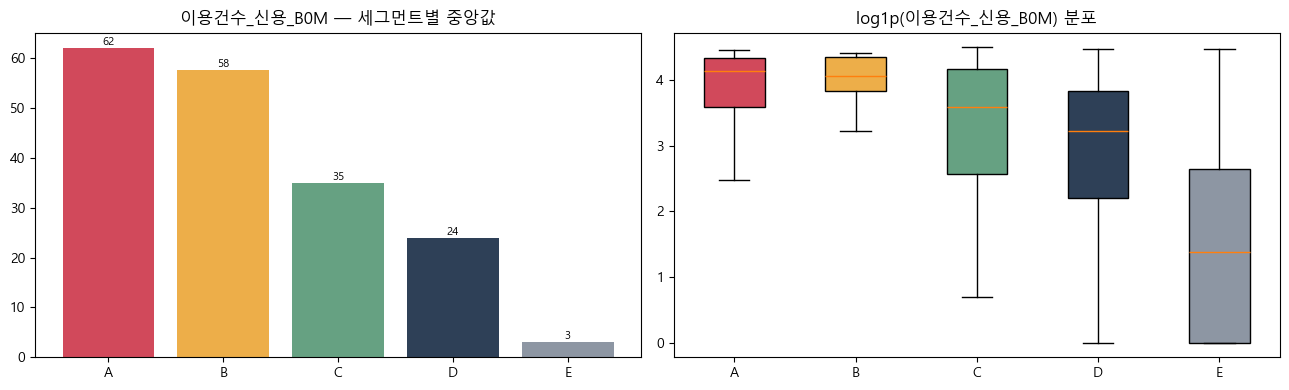

In [6]:
# 이용금액_신용_R3M 세그먼트별 분포 (E 지배 → 로그 스케일)
col = '이용금액_신용_R3M' if '이용금액_신용_R3M' in df.columns else rep[0]
fig, ax = plt.subplots(1,2, figsize=(13,4))
med = df.groupby('Segment')[col].median().reindex(SEG_ORDER)
ax[0].bar(SEG_ORDER, med.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title(f'{col} — 세그먼트별 중앙값')
for i,v in enumerate(med.values): ax[0].text(i,v,f'{v:,.0f}',ha='center',va='bottom',fontsize=8)
data=[np.log1p(df.loc[df['Segment']==s, col].clip(lower=0)) for s in SEG_ORDER]
bp=ax[1].boxplot(data, labels=SEG_ORDER, showfliers=False, patch_artist=True)
for p,s in zip(bp['boxes'],SEG_ORDER): p.set_facecolor(SEG_COLORS[s])
ax[1].set_title(f'log1p({col}) 분포'); plt.tight_layout(); plt.show()

## 4. Segment를 잘 가르는 수치형 피처 랭킹

406개 중 어떤 소비 피처가 A~E를 가장 잘 분리하는지. 스케일 보정한 분리도(sep_score) 상위.

In [7]:
drop = set(const_cols) | {'기준년월'}
num_cols = [c for c in df.columns
            if c not in drop and c not in ('ID','Segment') and pd.api.types.is_numeric_dtype(df[c])]
print('수치형 분석 대상:', len(num_cols))

med = df.groupby('Segment')[num_cols].median().reindex(SEG_ORDER).T
iqr = (df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)).replace(0, np.nan)
sep = ((med.max(axis=1) - med.min(axis=1)) / (iqr + 1e-9)).sort_values(ascending=False)
med_sorted = med.loc[sep.index]; med_sorted.insert(0,'sep_score', sep.round(2))
print('분리도 상위 30개 (세그먼트별 중앙값):')
med_sorted.head(30)

수치형 분석 대상: 345


분리도 상위 30개 (세그먼트별 중앙값):


Segment,sep_score,A,B,C,D,E
할부금액_무이자_3M_R12M,21.86,25113.5,60629.0,3444.0,2230.0,0.0
이용금액_페이_온라인_R6M,16.87,11486.0,18547.0,5092.0,1611.0,0.0
이용금액_할부_무이자_R12M,15.34,32783.5,86881.0,6939.0,4788.0,0.0
할부금액_3M_R12M,13.10,25914.5,60629.0,5126.0,3421.0,0.0
이용금액_페이_온라인_R3M,11.79,5828.0,9641.0,2816.0,1162.0,0.0
쇼핑_온라인_이용금액,11.46,9481.0,14037.0,2645.0,1309.0,0.0
연체입금원금_B0M,10.87,0.0,10646.0,3207.0,538.0,0.0
이용금액_할부_R12M,10.31,36660.0,87743.0,10104.0,7608.0,0.0
연체입금원금_B2M,9.45,0.0,9356.5,2995.0,550.0,0.0
_1순위쇼핑업종_이용금액,8.29,9722.5,14037.0,3347.0,1918.0,410.0


In [8]:
# 단조성 체크: A>=B>=C>=D>=E 또는 그 역으로 완전 정렬된 피처 (순서형 가설 부합)
def monotonic(row):
    v=row.values.astype(float)
    return np.all(np.diff(v)<=0) or np.all(np.diff(v)>=0)
mono = med.loc[sep.index[:60]].apply(monotonic, axis=1)
print(f'분리도 상위60 중 A→E 완전 단조 피처: {int(mono.sum())}개')
print('예시(단조 & 분리도 상위):')
print(med_sorted.loc[mono[mono].index].head(15).to_string())

분리도 상위60 중 A→E 완전 단조 피처: 25개
예시(단조 & 분리도 상위):
Segment          sep_score         A         B         C        D        E
이용금액_일시불_R12M         7.59  429999.5  341116.0  142176.0  83113.0  13389.5
정상입금원금_B0M            6.69   31691.0   14320.5   10790.0   5911.0    906.0
정상입금원금_B2M            6.28   31837.5   16447.0   11191.0   6263.0   1013.0
정상입금원금_B5M            5.89   30867.5   21951.0   10761.0   6218.0   1016.0
최대이용금액_일시불_R12M       5.74   61445.0   29434.0   23214.0  13566.0   2864.0
_3순위업종_이용금액           4.44    7379.0    5909.5    2927.0   1912.0      0.0
이용금액_일시불_B0M          4.39   22571.0   20339.5   11226.0   6385.0   1307.0
이용금액_일시불_R3M          4.32   67675.0   64192.5   33766.0  19439.0   4038.0
_2순위업종_이용금액           4.26   11052.5    9615.5    4543.0   2991.0    535.0
이용금액_일시불_R6M          4.13  134849.5  130347.0   68239.0  40034.0   8468.0
이용금액_오프라인_R3M         3.95   53524.5   49922.5   35341.0  28932.0   1819.0
이용금액_오프라인_R6M         3.93  111553.5   97100.0   71198

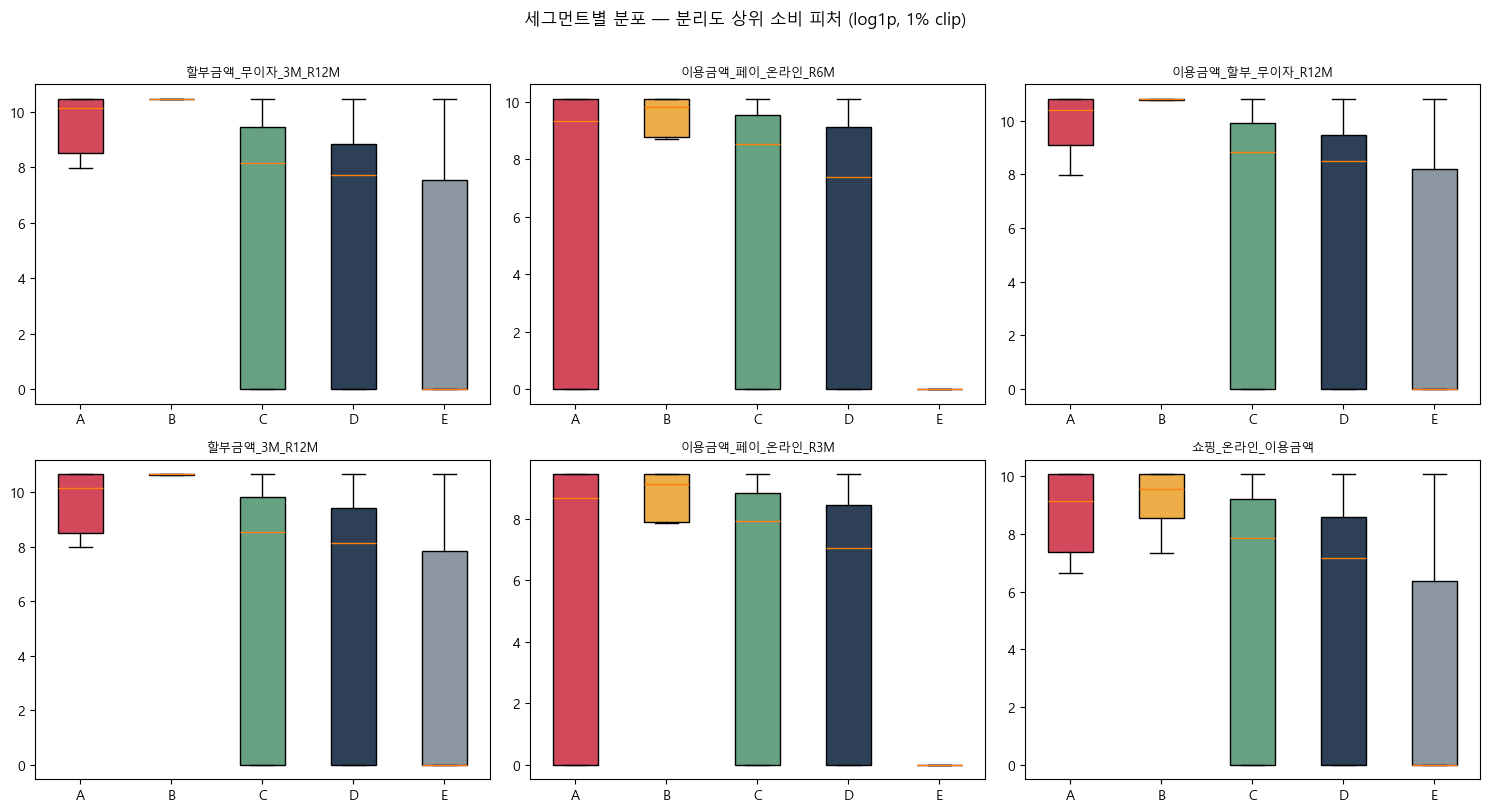

In [9]:
# 분리도 상위 6개 박스플롯 (log1p, 상위1% clip)
top_feats = sep.index[:6].tolist()
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, feat in zip(axes.ravel(), top_feats):
    data=[np.log1p(df.loc[df['Segment']==s, feat].clip(lower=0, upper=df[feat].quantile(0.99))) for s in SEG_ORDER]
    bp=ax.boxplot(data, labels=SEG_ORDER, showfliers=False, patch_artist=True)
    for p,s in zip(bp['boxes'],SEG_ORDER): p.set_facecolor(SEG_COLORS[s])
    ax.set_title(feat, fontsize=9)
plt.suptitle('세그먼트별 분포 — 분리도 상위 소비 피처 (log1p, 1% clip)', y=1.01)
plt.tight_layout(); plt.show()

## 5. 범주형 소비 성향 vs Segment

`이용금액대`(소비 금액 구간), `_1순위업종`(주 소비 업종) 등이 세그먼트와 어떻게 얽히는지.

In [10]:
cat_cols = [c for c in ['이용금액대','_1순위업종','_1순위쇼핑업종'] if c in df.columns]
for c in cat_cols:
    ct = pd.crosstab(df[c], df['Segment']).reindex(columns=SEG_ORDER, fill_value=0)
    row_pct=(ct.div(ct.sum(axis=1),axis=0)*100).round(1)
    out=row_pct.copy(); out['n']=ct.sum(axis=1)
    print(f'\n=== {c} : 값별 세그먼트 구성비(%) ===')
    print(out.sort_values('n', ascending=False).to_string())


=== 이용금액대 : 값별 세그먼트 구성비(%) ===
Segment      A    B     C     D     E      n
이용금액대                                       
09.미사용     0.0  0.0   0.9   3.6  95.5  86304
05.10만원-   0.0  0.0   0.9   4.1  95.0  75972
02.50만원+   0.0  0.0   3.5  25.9  70.6  74955
04.10만원+   0.0  0.0   1.4   7.2  91.5  56443
03.30만원+   0.0  0.0   1.0   5.9  93.1  53512
01.100만원+  0.3  0.0  30.2  47.9  21.6  52814

=== _1순위업종 : 값별 세그먼트 구성비(%) ===
Segment    A    B     C     D      E       n
_1순위업종                                      
쇼핑       0.1  0.0   9.3  23.3   67.3  171645
납부       0.0  0.0   1.9   7.6   90.5   69195
교통       0.0  0.0   2.6   9.7   87.7   32553
사교활동     0.0  0.0   7.5  22.8   69.8   12470
교육       0.0  0.0   5.4  16.6   77.9   12273
해외       0.0  0.0   4.4  12.7   82.8    3957
의료       0.1  0.0  11.8  13.6   74.4    2402
여유생활     0.0  0.0   3.7   4.4   91.9     136
일상생활     0.0  0.0   0.0   8.8   91.2      34
요식       0.0  0.0   0.0   0.0  100.0       1



=== _1순위쇼핑업종 : 값별 세그먼트 구성비(%) ===
Segment     A    B     C     D     E       n
_1순위쇼핑업종                                    
온라인       0.1  0.0  10.7  26.2  63.0  116149
도소매       0.1  0.0   7.4  17.7  74.8   63368
마트        0.0  0.0   3.2  14.7  82.1   33476
슈퍼마켓      0.0  0.0   2.5  12.7  84.7   16246
편의점       0.0  0.0   3.3  16.5  80.1    7026
백화점       0.0  0.0   3.2   8.5  88.4    2441
쇼핑기타      0.0  0.0   2.8   6.9  90.3     936
아울렛       0.0  0.0   0.9   6.0  93.2     117


## 6. 소수클래스 A / B 집중 — 회원정보에서 못 가른 A vs B를 소비로 가를 수 있나?

In [11]:
glob_med = df[num_cols].median()
a_med = df[df['Segment']=='A'][num_cols].median()
b_med = df[df['Segment']=='B'][num_cols].median()
cmp = pd.DataFrame({'A_median':a_med,'B_median':b_med,'ALL_median':glob_med})
# A와 B의 상대 차이가 큰 피처 (A vs B 분리 후보)
cmp['A_over_B'] = (a_med/(b_med.replace(0,np.nan))).round(2)
cmp['absdiff'] = (a_med-b_med).abs()
print('A vs B 중앙값 차이가 큰 피처 상위 20 (A/B 분리 후보):')
print(cmp.sort_values('absdiff', ascending=False).head(20).to_string())

A vs B 중앙값 차이가 큰 피처 상위 20 (A/B 분리 후보):
                    A_median    B_median  ALL_median  A_over_B     absdiff
최종이용일자_체크            10101.0  20130857.5     10101.0      0.00  20120756.5
이용금액_일시불_R12M       429999.5    341116.0     21500.5      1.26     88883.5
이용금액_할부_무이자_R12M     32783.5     86881.0         0.0      0.38     54097.5
이용금액_할부_R12M         36660.0     87743.0         0.0      0.42     51083.0
카드론이용금액_누적               0.0     50990.0         0.0      0.00     50990.0
이용금액_할부_R6M              0.0     35751.0         0.0      0.00     35751.0
이용금액_할부_무이자_R6M          0.0     35751.0         0.0      0.00     35751.0
할부금액_무이자_3M_R12M     25113.5     60629.0         0.0      0.41     35515.5
최종이용일자_CA         20140267.5  20175716.5     10101.0      1.00     35449.0
할부금액_3M_R12M         25914.5     60629.0         0.0      0.43     34714.5
최대이용금액_일시불_R12M      61445.0     29434.0      4263.0      2.09     32011.0
최종카드론_대출금액               0.0     28038.0         0.0      0.0

In [12]:
# 이용금액대 상에서 A/B 개수 분포
if '이용금액대' in df.columns:
    ab = df[df['Segment'].isin(['A','B'])].groupby(['이용금액대','Segment']).size().unstack(fill_value=0)
    ab = ab.reindex(columns=['A','B'], fill_value=0); ab['A+B']=ab.sum(axis=1)
    print('=== 이용금액대 : A/B 개수 ===')
    print(ab.sort_index().to_string())
if '_1순위업종' in df.columns:
    ab2 = df[df['Segment'].isin(['A','B'])].groupby(['_1순위업종','Segment']).size().unstack(fill_value=0)
    ab2 = ab2.reindex(columns=['A','B'], fill_value=0); ab2['A+B']=ab2.sum(axis=1)
    print('\n=== _1순위업종 : A/B 개수 ===')
    print(ab2.sort_values('A+B', ascending=False).to_string())

=== 이용금액대 : A/B 개수 ===
Segment      A   B  A+B
이용금액대                  
01.100만원+  162  24  186

=== _1순위업종 : A/B 개수 ===
Segment    A   B  A+B
_1순위업종               
쇼핑       139  24  163
교육         4   0    4
교통         4   0    4
납부         4   0    4
사교활동       4   0    4
의료         3   0    3


## 7. 요약 & 발견

### 순서형(A→E) 가설 = **강하게 확인됨**
소비 지표가 A→E로 거의 완벽히 단조 감소. 예: `이용금액_일시불_R12M` 중앙값 **A 430,000 → B 341,116 → C 142,176 → D 83,113 → E 13,390**. 분리도 상위 60개 중 **25개가 A→E 완전 단조**. 
→ Segment는 소비 규모 등급이 맞다. **소비 피처가 분류의 주력**이 될 것.

### 분리도 최상위 피처 (Segment를 가장 잘 가름)
`이용금액_일시불_R12M/R6M/R3M/B0M`, `최대이용금액_일시불_R12M`, `이용금액_오프라인_*`, `이용건수_신용/신판_B0M`, 업종별 이용금액(`_2·3순위업종_이용금액`, `쇼핑_도소매_이용금액`). 
- 흥미: `정상입금원금_B0M/B2M/B5M`(정상 입금 원금=상환 행동)도 분리도 최상위 → 청구/입금 카테고리(4)도 강할 것으로 예고.
- **장기 창(R12M/R6M)이 당월(B0M)보다 분리도가 대체로 높음** → 피처 집계 시 장기 누적 지표가 중요.

### 범주형 신호 — `이용금액대`가 결정적
- **`이용금액대`='01.100만원+' 구간에 A·B 100%가 존재** (162 A + 24 B 전원). 즉 A/B는 항상 최상위 소비 구간.
- 다만 그 100만원+ 구간 안에도 C 30% · D 48% · E 22%가 섞여 있어, **구간만으로 A/B를 대중과 분리하진 못함**(추가 피처 필요).
- `_1순위업종`: A/B는 대부분 **쇼핑**(A 139/162, B 24/24). 상위 세그일수록 온라인·도소매 쇼핑 비중↑.

### A vs B 분리 — 여전히 어려움
A와 B 모두 최상위 소비·쇼핑·100만원+ 구간으로 프로필이 겹침. A가 B보다 이용금액이 다소 높으나(예 일시불 R12M 430k vs 341k) 분포가 겹쳐 단일 피처로는 분리 곤란. **B(24명)는 회원+승인매출로도 명확히 안 갈림** → 모델에서 few-shot/threshold 특수처리 필요.

### 전처리 메모
- **상수 컬럼 43개** 제거(부분무이자·당사페이/기타·부분할부 계열 등 이 표본에서 전부 0).
- 고결측 16개는 대부분 2·3순위 업종 = **미소비 신호** → NaN을 '미사용' 범주 또는 0/플래그로 인코딩.

**다음 카테고리**: 4.청구입금(정상입금원금이 강력했음) 또는 5.잔액. 소비→상환/잔액 축으로 확장.